In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("Weight-Height Polynomial Dataset.csv")

In [20]:
df.describe()

,Weight,Height
count,50.000000,50.000000
mean,75.673912,111.473633
std,23.110656,39.493803
min,41.646760,68.971292
25%,54.701360,79.966731
50%,74.883900,98.819101
75%,91.988395,129.709758
max,117.592788,202.663424


In [5]:
x = df["Weight"]
y = df["Height"]

Text(0, 0.5, 'Height')

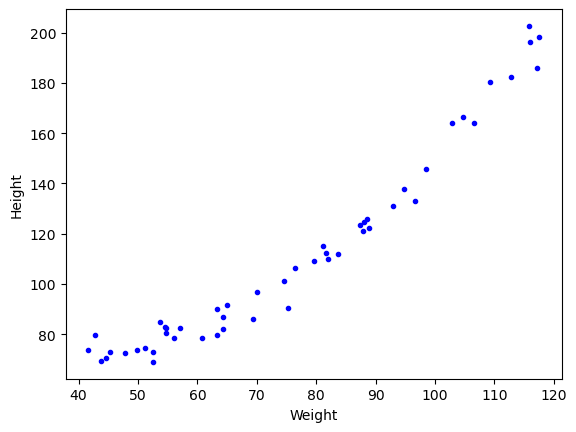

In [7]:
plt.plot(x,y,'b.')
plt.xlabel("Weight")
plt.ylabel("Height")

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [11]:
lr = LinearRegression()
lr.fit(x_train.values.reshape(-1,1),y_train)
y_pred = lr.predict(x_test.values.reshape(-1,1))
r2_score(y_test,y_pred)

0.5181986924754776

Text(0, 0.5, 'y')

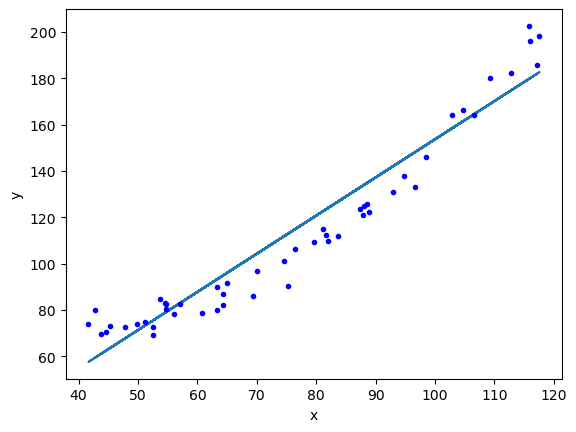

In [13]:
plt.plot(x_train,lr.predict(x_train.values.reshape(-1,1)))
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')

In [51]:
poly = PolynomialFeatures(degree=2,include_bias=True)

x_train_trans = poly.fit_transform(x_train.values.reshape(-1,1))
x_test_trans = poly.transform(x_test.values.reshape(-1,1))

In [52]:
lr = LinearRegression()
lr.fit(x_train_trans,y_train)
y_pred = lr.predict(x_test_trans)
r2_score(y_test,y_pred)

0.90202245454632

In [22]:
x_new=np.linspace(41, 117).reshape(50, 1)
x_new_poly = poly.transform(x_new)
y_new = lr.predict(x_new_poly)

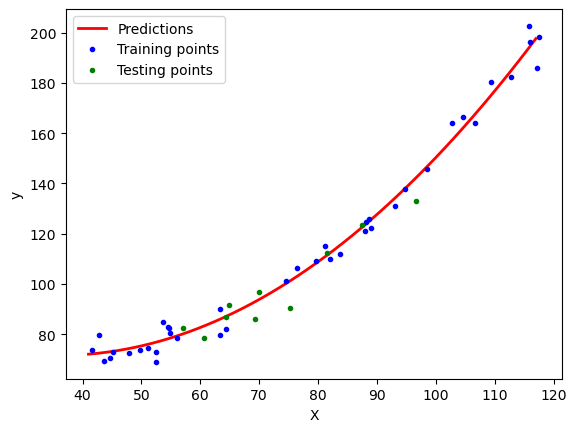

In [23]:
plt.plot(x_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()